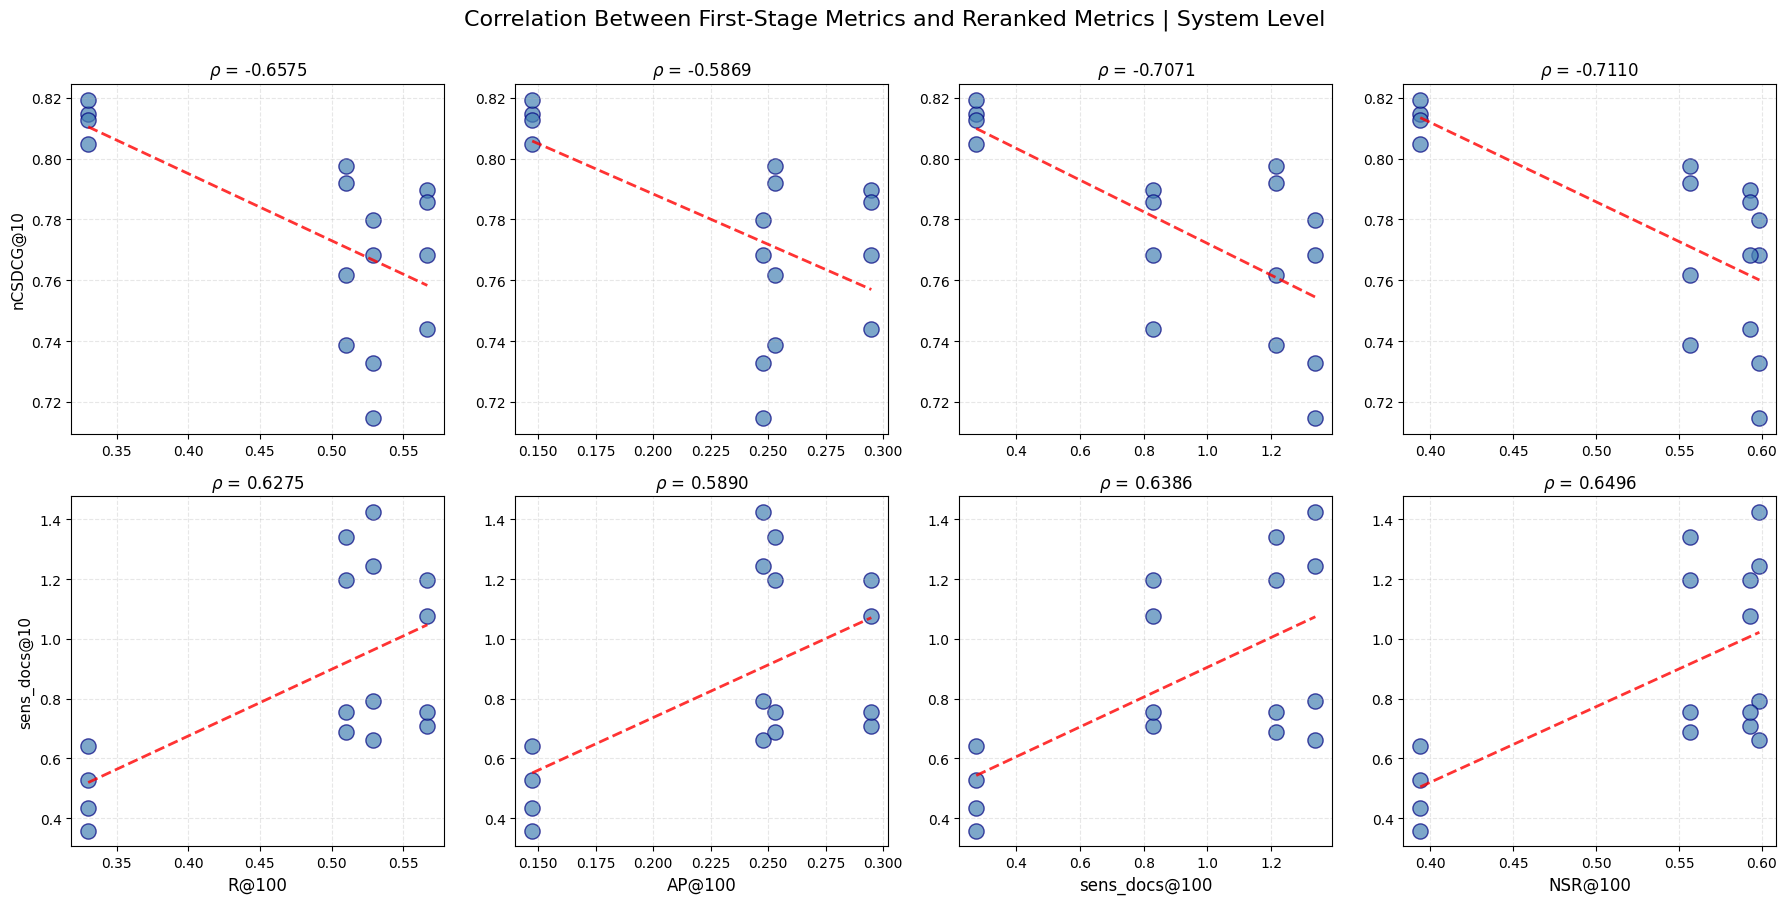

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Load your data
df = pd.read_csv("./runs_wo_filter_v2/results_w_paths.csv")
pairs = []

# Define first stage runs and their corresponding reranked versions
first_stage_runs = df[~df['name'].str.contains('monot5')].copy()

for _, first_stage in first_stage_runs.iterrows():
    base_name = first_stage['name']
    
    # Find all reranked versions of this first-stage run
    reranked = df[df['name'].str.contains('monot5') & 
                  df['name'].str.contains(base_name.replace(' % 100', '').strip())]
    
    for _, rerank in reranked.iterrows():
        pairs.append({
            'first_stage_name': base_name,
            'reranked_name': rerank['name'],
            # First stage metrics (using @100 versions as predictors)
            'R@100': first_stage['R@100'],
            'AP@100': first_stage['AP@100'],
            'sens_docs@100': first_stage['sens_docs@10'],  # This is actually @100 in first stage
            'NSR@100': first_stage['NSR@100'],
            # Second stage reranked metrics
            'nCSDCG@10_reranked': rerank['nCSDCG_cut_10'],
            'sens_docs@10_reranked': rerank['sens_docs@10']
        })

pairs_df = pd.DataFrame(pairs)

# print("=" * 80)
# print("FIRST-STAGE METRICS IMPACT ON RERANKING PERFORMANCE")
# print("=" * 80)
# print(f"\nAnalyzing {len(pairs_df)} first-stage → reranked pairs\n")

# # Show the pairs
# print("Matched pairs:")
# print("-" * 80)
# for _, row in pairs_df.iterrows():
#     print(f"{row['first_stage_name']:40s} → {row['reranked_name']}")

# First-stage metrics to analyze
first_stage_metrics = ['R@100', 'AP@100', 'sens_docs@100', 'NSR@100']
second_stage_metrics = ['nCSDCG@10_reranked', 'sens_docs@10_reranked']

# Calculate correlations
# print("\n\n" + "=" * 80)
# print("CORRELATION ANALYSIS")
# print("=" * 80)

correlation_results = {}

for second_metric in second_stage_metrics:
    display_name = second_metric.replace('_reranked', '')
    # print(f"\n\n{display_name} <- First-Stage Metrics:")
    # print("-" * 80)
    
    correlations = []
    for first_metric in first_stage_metrics:
        corr, p_value = pearsonr(pairs_df[first_metric], pairs_df[second_metric])
        correlations.append({
            'First-Stage Metric': first_metric,
            'Correlation': corr,
            'P-value': p_value,
            'Abs_Correlation': abs(corr)
        })
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    
    correlation_results[second_metric] = pd.DataFrame(correlations)
    
# Visualization
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Correlation Between First-Stage Metrics and Reranked Metrics | System Level', 
             fontsize=16, y=1.00)

for idx, second_metric in enumerate(second_stage_metrics):
    display_name = second_metric.replace('_reranked', '')
    for jdx, first_metric in enumerate(first_stage_metrics):
        ax = axes[idx, jdx]
        
        # Scatter plot
        ax.scatter(pairs_df[first_metric], pairs_df[second_metric], 
                  s=120, alpha=0.7, color='steelblue', edgecolors='navy', linewidth=1)
        
        # Add trend line
        z = np.polyfit(pairs_df[first_metric], pairs_df[second_metric], 1)
        p = np.poly1d(z)
        x_line = np.linspace(pairs_df[first_metric].min(), pairs_df[first_metric].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        # Calculate correlation
        corr, p_val = pearsonr(pairs_df[first_metric], pairs_df[second_metric])
        
        # Labels and styling
        # ax.set_xlabel(first_metric, fontsize=11)
        if jdx == 0:
            ax.set_ylabel(display_name, fontsize=11)
        
        # Title with correlation and significance
        ax.set_title(fr'$\rho$ = {corr:.4f}', fontsize=12)
        ax.grid(True, alpha=0.3, linestyle='--')

for jdx, first_metric in enumerate(first_stage_metrics):
    axes[1, jdx].set_xlabel(first_metric, fontsize=12)

plt.tight_layout()
# plt.savefig("./per_system_correlation.pdf", dpi = 1080)
# plt.savefig("./per_system_correlation.png", dpi = 1080)
plt.show()

Per-query matched pairs: 1696


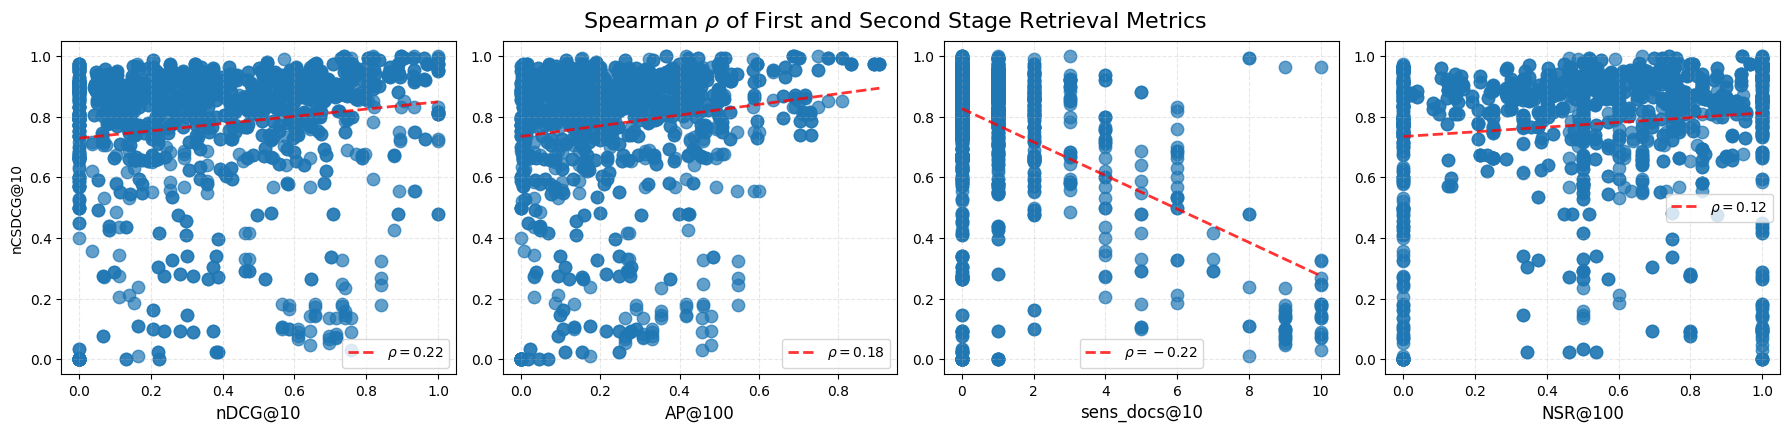

In [53]:
# ------------------------------------------------------------------------------------
# 1. Pivot your per-query dataframe into wide format
# ------------------------------------------------------------------------------------

df = pd.read_csv("./runs_wo_filter_v2/results_w_paths_extra_metrics_perquery.csv")
df_q = df.pivot(index=["name", "qid"], columns="measure", values="value").reset_index()

# ------------------------------------------------------------------------------------
# 2. Build per-query matching pairs: first-stage → reranked
# ------------------------------------------------------------------------------------
pairs_q = []

first_stage_q = df_q[~df_q['name'].str.contains("monot5")].copy()

for _, first_stage in first_stage_q.iterrows():
    base_name = first_stage['name']
    qid = first_stage['qid']
    
    # Match reranked runs with same qid + same base_name prefix
    reranked = df_q[
        (df_q['name'].str.contains("monot5")) &
        (df_q['name'].str.contains(base_name.replace(" % 100", "").strip())) &
        (df_q['qid'] == qid)
    ]
    
    for _, rer in reranked.iterrows():
        pairs_q.append({
            "name": base_name,
            "qid": qid,
            "reranked_name": rer["name"],
            # first-stage metrics
            "nDCG@10": first_stage.get("nDCG@10"),
            "AP@100": first_stage.get("AP@100"),
            "sens_docs@10": first_stage.get("sens_docs@10"),
            "NSR@100": first_stage.get("NSR@100"),
            # reranked metrics
            "nCSDCG@10_reranked": rer.get("nCSDCG_cut_10"),
            # "sens_docs@10_reranked": rer.get("sens_docs@10"),
        })

pairs_q_df = pd.DataFrame(pairs_q)
print("Per-query matched pairs:", len(pairs_q_df))

# ------------------------------------------------------------------------------------
# 3. Make the same 2×4 correlation plot (per-query version)
# ------------------------------------------------------------------------------------
first_stage_metrics = ['nDCG@10', 'AP@100', 'sens_docs@10', 'NSR@100']
# second_stage_metrics = ['nCSDCG@10_reranked', 'sens_docs@10_reranked']
second_stage_metrics = ['nCSDCG@10_reranked']


# fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

fig.suptitle(r'Spearman $\rho$ of First and Second Stage Retrieval Metrics',
             fontsize=16, y=0.95)

for row_idx, second_metric in enumerate(second_stage_metrics):
    display_name = second_metric.replace("_reranked", "")
    for col_idx, first_metric in enumerate(first_stage_metrics):
        # ax = axes[row_idx, col_idx]
        ax = axes[col_idx]

        x = pairs_q_df[first_metric]
        y = pairs_q_df[second_metric]

        # Scatter plot
        ax.scatter(x, y, s=80, alpha=0.7)

        # Trend line
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        xp = np.linspace(x.min(), x.max(), 200)
        corr, pval = spearmanr(x, y)
        # print(corr)
        ax.plot(xp, p(xp), "r--", alpha=0.8, linewidth=2, label=fr"$\rho = {corr:.2f}$")
        ax.legend()
        # Correlation coefficient
        

        # Labels & title
        # ax.set_xlabel(first_metric, fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(display_name, fontsize=10)

        # ax.set_title(f"r = {corr:.4f}", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.3)

# for jdx, first_metric in enumerate(first_stage_metrics):
#     axes[1, jdx].set_xlabel(first_metric, fontsize=12)

for jdx, first_metric in enumerate(first_stage_metrics):
    axes[jdx].set_xlabel(first_metric, fontsize=12)
    
plt.tight_layout()
plt.savefig("./plots/per_query_impact_analysis_v5.png", dpi=1080)
plt.savefig("./plots/per_query_impact_analysis_v5.pdf", dpi=1080)

plt.show()

In [49]:
spearmanr(pairs_q_df["nDCG@10"], pairs_q_df["nCSDCG@10_reranked"])

SignificanceResult(statistic=0.2186399015828223, pvalue=8.39809496577562e-20)